1. Problem Framing

# TELCO CUSTOMER CHURN PREDICTION

## Problem Framing

A telecom company is facing customer churn, where customers leave the company and switch to competitors. This results in loss of revenue and additional customer acquisition costs.

The objective is to build a Machine Learning model that can identify customers who are likely to churn so that the company can take proactive retention actions.

### Business Objective
Predict whether a customer is likely to:
- Churn
- Stay

### Machine Learning Problem
This is a **binary classification problem**.

### Target Variable
Churn

- Yes → Customer is likely to churn
- No → Customer is likely to stay

### Model
Logistic Regression

Import libraries and load dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [19]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


2 — Identify relevant input features

In [20]:
df = df.drop('customerID', axis=1)

In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [22]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [24]:
df = df.dropna()

3 — Prepare the target variable

In [25]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [26]:
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


4 — Convert categorical features into numbers

In [27]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [28]:
X = pd.get_dummies(X, drop_first=True)

In [29]:
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

5 — Split the data into training and testing data

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


6 — Build the churn prediction model

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


c:\Users\JAKKANA HASINI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


7 — Predict churn for unseen customers


In [34]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 ... 0 0 0]


8 — Predict the probability of churn

In [35]:
y_probability = model.predict_proba(X_test)[:, 1]

print(y_probability[:10])

[0.01803384 0.58326644 0.00457417 0.20396093 0.10528705 0.47917863
 0.02524995 0.16636368 0.66764473 0.01544408]


9 — Classify customers into Likely to Churn / Likely to Stay

In [36]:
churn_status = np.where(
    y_probability >= 0.5,
    "Likely to Churn",
    "Likely to Stay"
)

print(churn_status[:20])

['Likely to Stay' 'Likely to Churn' 'Likely to Stay' 'Likely to Stay'
 'Likely to Stay' 'Likely to Stay' 'Likely to Stay' 'Likely to Stay'
 'Likely to Churn' 'Likely to Stay' 'Likely to Churn' 'Likely to Stay'
 'Likely to Churn' 'Likely to Stay' 'Likely to Stay' 'Likely to Churn'
 'Likely to Churn' 'Likely to Churn' 'Likely to Stay' 'Likely to Stay']


In [37]:
results = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Churn Probability': y_probability,
    'Prediction': churn_status
})

print(results.head(10))


   Actual Churn  Churn Probability       Prediction
0             0           0.018034   Likely to Stay
1             0           0.583266  Likely to Churn
2             0           0.004574   Likely to Stay
3             1           0.203961   Likely to Stay
4             0           0.105287   Likely to Stay
5             1           0.479179   Likely to Stay
6             0           0.025250   Likely to Stay
7             0           0.166364   Likely to Stay
8             1           0.667645  Likely to Churn
9             0           0.015444   Likely to Stay


10 — Evaluate the model

In [38]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Accuracy : 0.8031272210376688
Precision: 0.6456456456456456
Recall   : 0.5748663101604278
F1 Score : 0.6082036775106082


11 — Analyze correctly identified churn customers and misclassified customers

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [159 215]]


In [40]:
print("Confusion Matrix")
print("----------------")
print("True Negative :", cm[0, 0])
print("False Positive:", cm[0, 1])
print("False Negative:", cm[1, 0])
print("True Positive :", cm[1, 1])

Confusion Matrix
----------------
True Negative : 915
False Positive: 118
False Negative: 159
True Positive : 215


In [41]:
print("Correctly identified churn customers:", cm[1, 1])
print("Non-churn customers misclassified:", cm[0, 1])

Correctly identified churn customers: 215
Non-churn customers misclassified: 118


12 — Display the confusion matrix visually

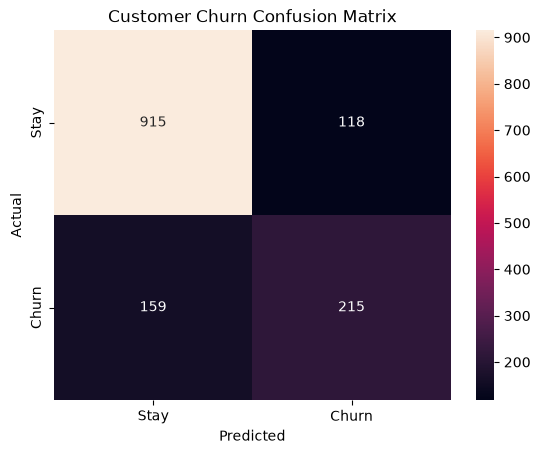

In [42]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Stay', 'Churn'],
    yticklabels=['Stay', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Churn Confusion Matrix")

plt.show()